In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 확인
print("폰트 설정 완료!")

폰트 설정 완료!


In [8]:
# 코호트 컬럼 생성

# Customer ID 없는 행 제거 (코호트 분석 불가)
df = df.dropna(subset=['Customer ID'])

# 각 거래가 속한 '연-월' (일 단위 제거)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 고객별 첫 구매월 = 코호트
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')

# 코호트로부터 몇 개월 경과 (0=첫 구매달)
df['PeriodNumber'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

print(df[['Customer ID', 'CohortMonth', 'PeriodNumber']].head())

  Customer ID CohortMonth  PeriodNumber
0       13085     2009-12             0
1       13085     2009-12             0
2       13085     2009-12             0
3       13085     2009-12             0
4       13085     2009-12             0


=== 코호트별 N개월 이내 재구매율 (2009-12 ~ 2010-10) ===
            고객수  재구매_1M  재구매_3M  재구매_6M  재구매_12M
CohortStr                                       
2009-12    1040    36.9    64.2    78.5     88.4
2010-01     360    23.6    57.8    75.6     87.2
2010-02     361    29.4    54.8    68.1     81.2
2010-03     425    22.1    46.4    63.3     77.9
2010-04     287    23.3    41.5    62.0     72.8
2010-05     255    19.2    38.0    62.0     69.8
2010-06     261    21.8    41.4    61.7     68.6
2010-07     183    20.8    46.4    60.1     69.4
2010-08     160    23.8    52.5    54.4     65.0
2010-09     236    29.2    47.9    56.8     66.9
2010-10     375    30.4    41.6    50.1     61.9


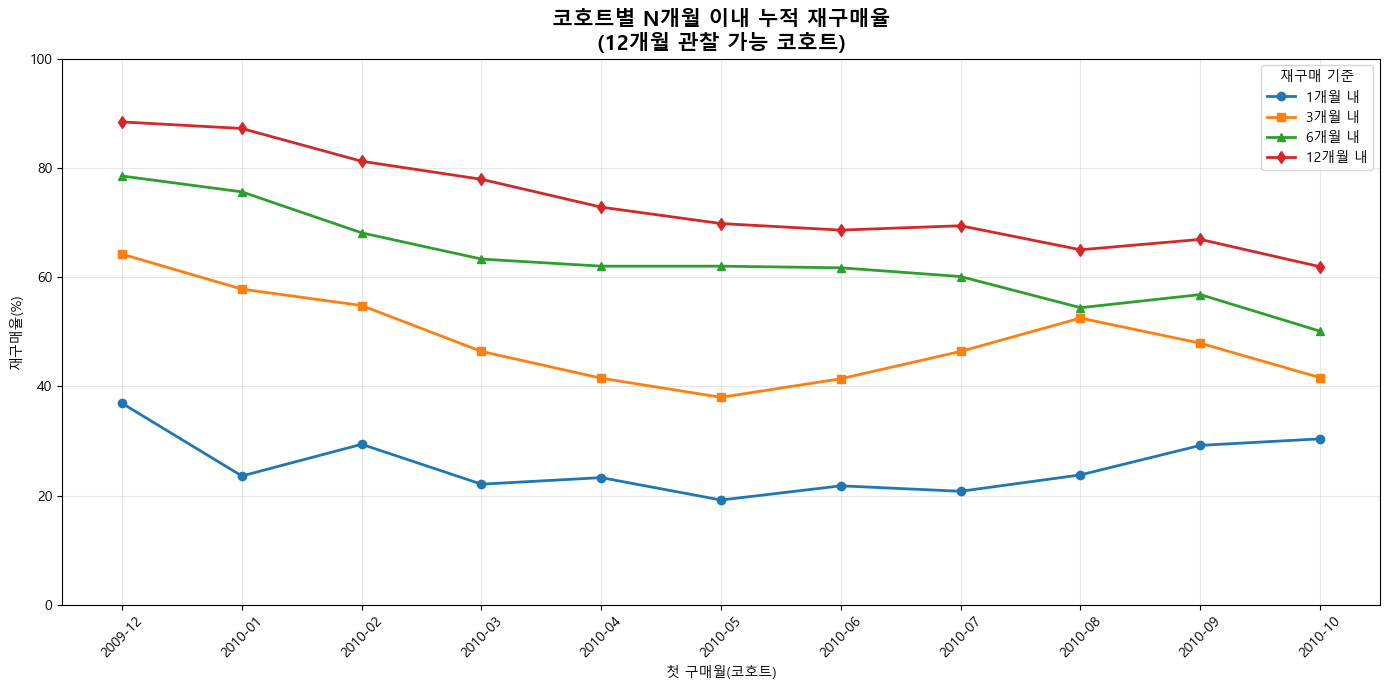


=== 인사이트 ===
12개월 이내 재구매율 최고: 2009-12 (88.4%)
12개월 이내 재구매율 최저: 2010-10 (61.9%)
코호트별 평균 12개월 이내 재구매율: 73.6%


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# =========================================================
# 1. 거래별 N개월 이내 재구매 조건 생성
# PeriodNumber = 0 : 첫 구매월
# PeriodNumber = 1 : 첫 구매 다음 달
# =========================================================

repurchase_df = df.copy()

repurchase_df['Repurchased_1M'] = (
    repurchase_df['PeriodNumber'].between(1, 1)
).astype(int)

repurchase_df['Repurchased_3M'] = (
    repurchase_df['PeriodNumber'].between(1, 3)
).astype(int)

repurchase_df['Repurchased_6M'] = (
    repurchase_df['PeriodNumber'].between(1, 6)
).astype(int)

repurchase_df['Repurchased_12M'] = (
    repurchase_df['PeriodNumber'].between(1, 12)
).astype(int)


# =========================================================
# 2. 고객별 재구매 여부 계산
# 기간 내 거래가 하나라도 있으면 max()가 1
# =========================================================

customer_repurchase = (
    repurchase_df
    .groupby('Customer ID', as_index=False)
    .agg(
        CohortMonth=('CohortMonth', 'first'),
        Repurchased_1M=('Repurchased_1M', 'max'),
        Repurchased_3M=('Repurchased_3M', 'max'),
        Repurchased_6M=('Repurchased_6M', 'max'),
        Repurchased_12M=('Repurchased_12M', 'max')
    )
)

# YYYY-MM 형태로 변환
customer_repurchase['CohortStr'] = (
    customer_repurchase['CohortMonth']
    .astype(str)
    .str[:7]
)


# =========================================================
# 3. 코호트별 N개월 이내 재구매율 계산
# =========================================================

cohort_repurchase = (
    customer_repurchase
    .groupby('CohortStr')
    .agg(
        고객수=('Customer ID', 'count'),
        재구매_1M=('Repurchased_1M', lambda x: x.mean() * 100),
        재구매_3M=('Repurchased_3M', lambda x: x.mean() * 100),
        재구매_6M=('Repurchased_6M', lambda x: x.mean() * 100),
        재구매_12M=('Repurchased_12M', lambda x: x.mean() * 100)
    )
    .round(1)
    .sort_index()
)


# =========================================================
# 4. 12개월 관찰 가능한 코호트만 사용
# =========================================================

cohort_repurchase = cohort_repurchase.loc[:'2010-10']

print("=== 코호트별 N개월 이내 재구매율 (2009-12 ~ 2010-10) ===")
print(cohort_repurchase.to_string())


# =========================================================
# 5. 시각화
# =========================================================

fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(cohort_repurchase))

ax.plot(
    x,
    cohort_repurchase['재구매_1M'],
    marker='o',
    label='1개월 내',
    linewidth=2
)

ax.plot(
    x,
    cohort_repurchase['재구매_3M'],
    marker='s',
    label='3개월 내',
    linewidth=2
)

ax.plot(
    x,
    cohort_repurchase['재구매_6M'],
    marker='^',
    label='6개월 내',
    linewidth=2
)

ax.plot(
    x,
    cohort_repurchase['재구매_12M'],
    marker='d',
    label='12개월 내',
    linewidth=2
)

ax.set_xticks(list(x))
ax.set_xticklabels(cohort_repurchase.index, rotation=45)

ax.set_title(
    '코호트별 N개월 이내 누적 재구매율\n(12개월 관찰 가능 코호트)',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('첫 구매월(코호트)')
ax.set_ylabel('재구매율(%)')
ax.set_ylim(0, 100)
ax.legend(title='재구매 기준')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'cohort_repurchase_within_12months.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# =========================================================
# 6. 인사이트
# =========================================================

print("\n=== 인사이트 ===")

print(
    f"12개월 이내 재구매율 최고: "
    f"{cohort_repurchase['재구매_12M'].idxmax()} "
    f"({cohort_repurchase['재구매_12M'].max():.1f}%)"
)

print(
    f"12개월 이내 재구매율 최저: "
    f"{cohort_repurchase['재구매_12M'].idxmin()} "
    f"({cohort_repurchase['재구매_12M'].min():.1f}%)"
)

print(
    f"코호트별 평균 12개월 이내 재구매율: "
    f"{cohort_repurchase['재구매_12M'].mean():.1f}%"
)

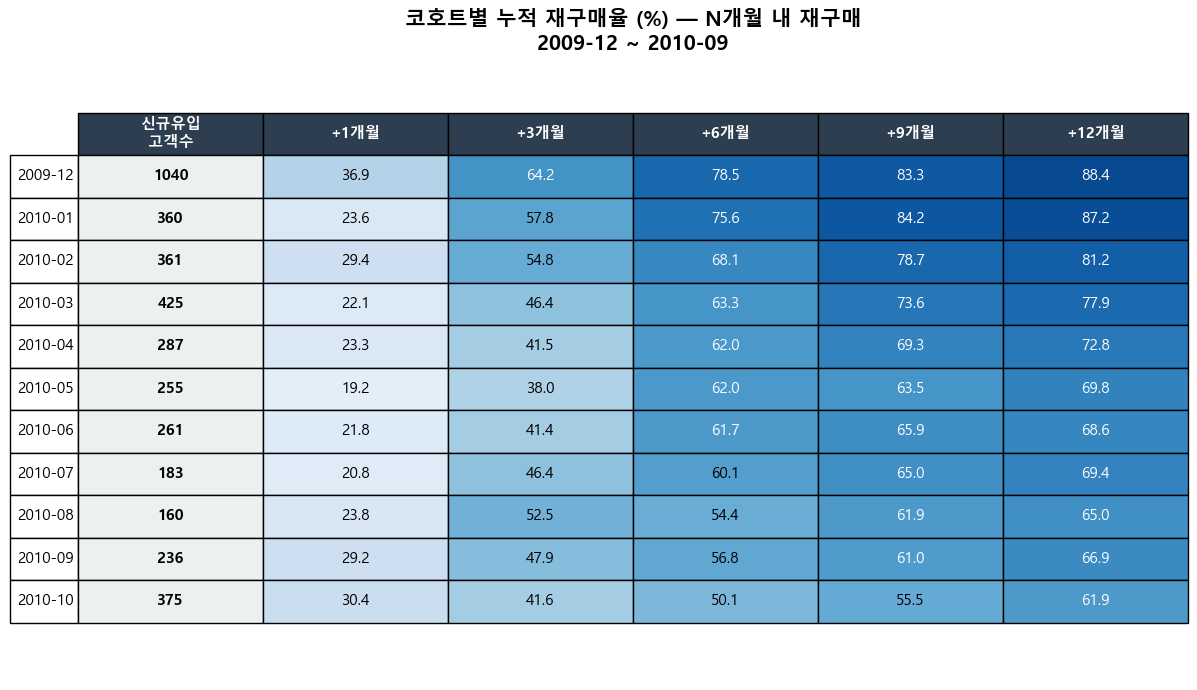

=== 누적 재구매율 표 ===
         +1개월  +3개월  +6개월  +9개월  +12개월
Cohort                                
2009-12  36.9  64.2  78.5  83.3   88.4
2010-01  23.6  57.8  75.6  84.2   87.2
2010-02  29.4  54.8  68.1  78.7   81.2
2010-03  22.1  46.4  63.3  73.6   77.9
2010-04  23.3  41.5  62.0  69.3   72.8
2010-05  19.2  38.0  62.0  63.5   69.8
2010-06  21.8  41.4  61.7  65.9   68.6
2010-07  20.8  46.4  60.1  65.0   69.4
2010-08  23.8  52.5  54.4  61.9   65.0
2010-09  29.2  47.9  56.8  61.0   66.9
2010-10  30.4  41.6  50.1  55.5   61.9


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# =========================================================
# 1. 고객별 첫 재구매 시점 계산
#    FirstRepurchase = 첫 구매 이후 처음 재구매까지 걸린 개월 수
#    재구매 없으면 NaN
# =========================================================

customer_repurchase = df.groupby('Customer ID').agg(
    CohortMonth     = ('CohortMonth', 'first'),
    FirstRepurchase = ('PeriodNumber', lambda x: x[x >= 1].min())
).reset_index()

customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)


# =========================================================
# 2. 코호트별 N개월 이내 누적 재구매율 계산
#    N개월 내 재구매 = 첫 재구매가 p개월 이내 (FirstRepurchase <= p)
# =========================================================

periods = [1, 3, 6, 9, 12]
cohort_list = sorted(customer_repurchase['CohortStr'].unique())

cumulative_data = []
for cohort in cohort_list:
    cohort_customers = customer_repurchase[
        customer_repurchase['CohortStr'] == cohort
    ]
    row = {'Cohort': cohort, '신규유입': len(cohort_customers)}
    for p in periods:
        rate = (cohort_customers['FirstRepurchase'] <= p).mean() * 100
        row[f'+{p}개월'] = rate
    cumulative_data.append(row)

cumulative_df = pd.DataFrame(cumulative_data).set_index('Cohort')


# =========================================================
# 3. 2010-09까지만 (12개월 관찰 가능)
# =========================================================

cumulative_df = cumulative_df[cumulative_df.index <= '2010-10']


# =========================================================
# 4. 표 그리기
# =========================================================

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['신규유입\n고객수'] + [f'+{p}개월' for p in periods]
row_labels = cumulative_df.index.tolist()

cell_text = []
for cohort in cumulative_df.index:
    row = [f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        val = cumulative_df.loc[cohort, f'+{p}개월']
        row.append(f'{val:.1f}')
    cell_text.append(row)

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.2)

# 색상: 재구매율 높을수록 진한 파랑
value_cols = [f'+{p}개월' for p in periods]
all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()

blues = plt.cm.Blues

for i, cohort in enumerate(cumulative_df.index):
    for j, p in enumerate(periods):
        val = cumulative_df.loc[cohort, f'+{p}개월']
        cell = table[i+1, j+1]
        norm = (val - vmin) / (vmax - vmin)
        color = blues(0.1 + norm * 0.8)
        cell.set_facecolor(color)
        if norm > 0.6:
            cell.set_text_props(color='white')

# 헤더
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 신규유입 컬럼
for i in range(len(row_labels)):
    table[i+1, 0].set_facecolor('#ecf0f1')
    table[i+1, 0].set_text_props(fontweight='bold')

plt.title('코호트별 누적 재구매율 (%) — N개월 내 재구매\n2009-12 ~ 2010-09',
          fontsize=15, fontweight='bold', pad=1)
plt.tight_layout()
plt.savefig('cohort_cumulative_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== 누적 재구매율 표 ===")
print(cumulative_df[value_cols].round(1).to_string())